# Funding-Rate Carry, Venue by Venue — with `candlefeed`

**The question:** if you run the classic delta-neutral carry trade — short the perp, hold the hedge, collect funding every 8 hours — *which exchange actually pays you the most*, and what does that translate to as an annualised yield?

Funding isn't a single number. The same BTC perp funds at different rates on Binance, Bybit and OKX at the same instant, and the gaps are large enough to matter to a carry book. This notebook uses the official [CandleFeed](https://candlefeed.ai) Python client to:

1. Pull the **OI-weighted aggregated funding** across Binance / Bybit / OKX — the single number that best represents "the market's" funding.
2. Pull each venue's **raw funding series** and rank them by what a short-perp carry actually collected.
3. Annualise the carry and be honest about what this does and doesn't prove.

Every call returns a tidy pandas DataFrame indexed by time, so the analysis is mostly `.resample()`, `.cumsum()` and `.plot()` from here.

> **Data note (honest framing):** the window below is short by choice, not by necessity — it's a *method on real data*, not a multi-year backtest. Funding history is deep on Binance (2020) and on Hyperliquid (hourly from each contract's HL listing — BTC/ETH/SOL from 2023-05-12); the other venues are shallower (OKX Dec 2025, Bybit Jan 2026, dYdX Mar 2026), so a genuinely cross-venue carry study is bounded by the newest venue in the basket. Widen `START` if you want the long Binance-only version.


In [1]:
# pip install candlefeed matplotlib pandas
import os
import pandas as pd
import matplotlib.pyplot as plt
from candlefeed import CandleFeed

# Reads the key from CANDLEFEED_API_KEY. Get one at https://candlefeed.ai
cf = CandleFeed()
print("Connected to CandleFeed:", cf.status()["status"])

Connected to CandleFeed: ok


## 1. Aggregated funding across venues (needs the Builder plan or above)

`get_funding_rates_aggregated` returns the open-interest-weighted funding rate across the exchanges where CandleFeed has both funding and OI. It's the cleanest single proxy for "what is the market paying to be short the perp right now."

The aggregated rate is normalised to a **per-hour** basis (the response says `funding_rate_basis="per_hour"`), so hourly venues like Hyperliquid and 8-hour venues like Binance can be weighted together. A bucket only appears where a venue settled, so on this 8-hour basket the rows land every 8 hours, but each value is still a per-hour rate.

In [ ]:
SYMBOL = "BTCUSDT"
START, END = "2026-05-10", "2026-06-08"   # the live forward-capture window

agg = cf.get_funding_rates_aggregated(
    SYMBOL,
    interval="1h",
    exchanges=["binance", "bybit", "okx"],
    start=START,
    end=END,
)
agg = agg[agg.index.notna()]
agg[["weighted_funding_rate", "total_oi_usd", "exchange_count", "contributing_exchanges"]].head()

Binance, Bybit and OKX settle funding every 8 hours, so the series has one row per settlement. Each row is the OI-weighted rate *per hour*, so a short-perp position collected 8 times that value at each settlement. The cumulative carry below sums those settlements. That 8-hour cadence is an assumption about this basket: a basket that includes hourly venues such as Hyperliquid needs each venue's own rate and cadence, which section 2 uses.

In [ ]:
wfr = agg["weighted_funding_rate"].dropna()          # OI-weighted rate per hour, one row per settlement
hourly = wfr * 100                                   # % per hour, for the top chart

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
hourly.plot(ax=ax1, lw=0.9, marker=".", ms=3)
ax1.axhline(0, color="k", lw=0.6)
ax1.set_title(f"{SYMBOL} OI-weighted funding rate per hour, at each settlement")
ax1.set_ylabel("% per hour")

# This basket settles every 8 hours: each settlement paid 8 hours of the hourly rate.
((wfr * 8).cumsum() * 100).plot(ax=ax2, color="C2", drawstyle="steps-post")
ax2.set_title("Cumulative short-perp carry collected (8-hour settlements, rate per hour x 8)")
ax2.set_ylabel("cumulative %")
ax2.axhline(0, color="k", lw=0.6)
plt.tight_layout()

total_pct = (wfr * 8).sum() * 100                    # 8 hours per settlement
annualised = wfr.mean() * 24 * 365 * 100             # per-hour rate, 24 hours a day
print(f"Weighted funding collected over window: {total_pct:.3f}%")
print(f"Implied annualised carry:               {annualised:.2f}%")

## 2. Per-exchange funding — which venue pays best?

The aggregate hides the dispersion. Pulling each venue's raw funding lets you pick the richest one to short. A practical wrinkle on real data: some raw funding rows carry a null timestamp, and timestamps can collide — so we drop `NaT`, de-duplicate, and resample to a clean 8-hour grid before comparing. (This is exactly the kind of cleaning a real carry desk does.)


In [4]:
venues = ["binance", "bybit", "okx"]
series = {}
for ex in venues:
    fr = cf.get_funding_rates(SYMBOL, exchange=ex, start=START, end=END)["funding_rate"]
    fr = fr[fr.index.notna()].sort_index()           # drop null timestamps
    fr = fr[~fr.index.duplicated(keep="last")]        # de-dup colliding stamps
    series[ex] = fr.resample("8h").sum()              # align to settlement grid

funding = pd.DataFrame(series).fillna(0.0)
funding.describe().round(6)

,binance,bybit,okx
count,88.000000,88.000000,88.000000
mean,0.000023,0.000028,0.000038
std,0.000033,0.000040,0.000043
min,-0.000028,-0.000091,-0.000078
25%,0.000000,-0.000000,0.000011
50%,0.000000,0.000027,0.000034
75%,0.000048,0.000052,0.000069
max,0.000100,0.000100,0.000100


Total funding collected over the window (%):
binance    0.1991
bybit      0.2441
okx        0.3325

Annualised carry by venue (%):
binance    2.48
bybit      3.04
okx        4.14


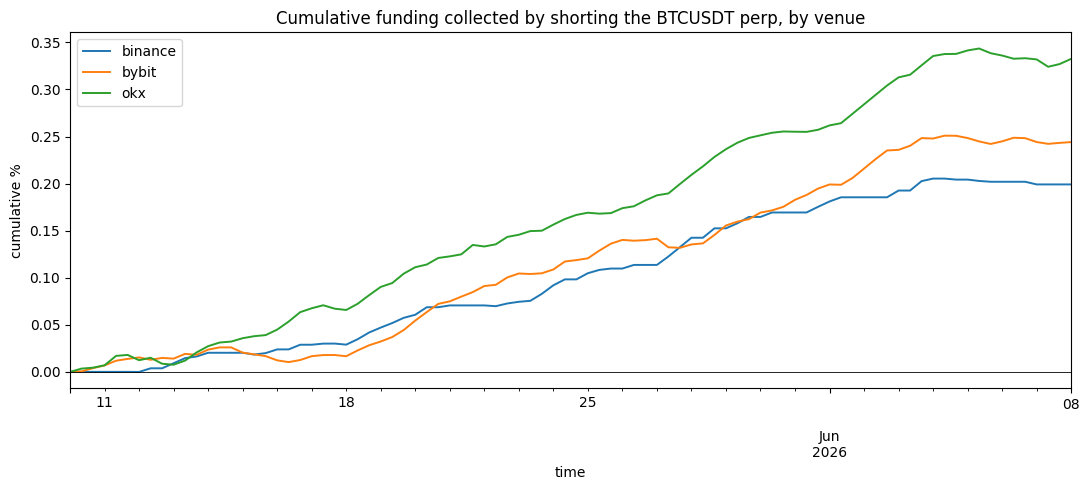

In [5]:
cum = funding.cumsum() * 100
ax = cum.plot(figsize=(11, 5), lw=1.4,
              title=f"Cumulative funding collected by shorting the {SYMBOL} perp, by venue")
ax.set_ylabel("cumulative %")
ax.axhline(0, color="k", lw=0.6)
plt.tight_layout()

print("Total funding collected over the window (%):")
print((funding.sum() * 100).round(4).to_string())
print("\nAnnualised carry by venue (%):")
print((funding.mean() * 3 * 365 * 100).round(2).to_string())

On this window the venues are **not** interchangeable: the richest venue paid noticeably more carry than the cheapest. That spread is the entire point of pulling per-venue data — a carry book that always shorts the highest-funding venue earns the top line, not the average. (Run the cell above to see the exact ranking on the live data; on the captured window OKX has been the richest of the three.)


## 3. Carry yield, and an honest accounting

The cumulative sum above is the **gross** funding collected by a 1-unit short perp. To turn it into a yield we annualise the mean per-settlement rate (≈3 settlements/day on these venues):


Richest venue on this window: okx
Settlements:                  88
Gross funding collected:      0.332%
Annualised gross carry:       4.14%


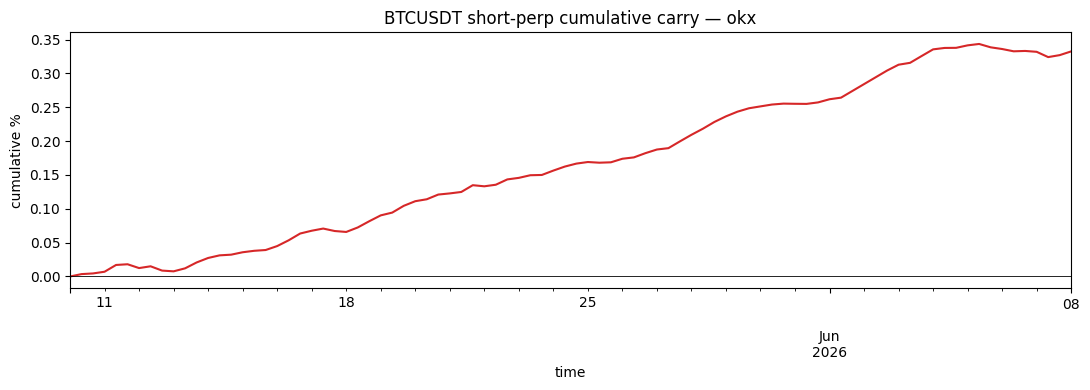

In [6]:
best = (funding.sum()).idxmax()
gross = funding[best]
ann = gross.mean() * 3 * 365 * 100

print(f"Richest venue on this window: {best}")
print(f"Settlements:                  {gross.shape[0]}")
print(f"Gross funding collected:      {gross.sum()*100:.3f}%")
print(f"Annualised gross carry:       {ann:.2f}%")

gross.cumsum().mul(100).plot(figsize=(11, 4), color="C3",
    title=f"{SYMBOL} short-perp cumulative carry — {best}")
plt.ylabel("cumulative %"); plt.axhline(0, color="k", lw=0.6); plt.tight_layout()

## What this is — and isn't

This is a **method on real data**, not a tradeable backtest. A live carry book has to net out everything the gross number ignores:

- **Hedge cost & basis drift** — shorting the perp leaves you long spot (or long another venue). Financing and basis moves both bite, and basis can move against you faster than funding accrues.
- **Funding sign flips** — funding goes negative in bearish regimes, inverting the trade. You can see candidate flips directly in the per-venue series above.
- **Fees, slippage and liquidation risk** on the short leg — a violent pump can blow through your liquidation price before margin arrives.
- **Sample length** — this is ~one month of forward-captured funding. Treat the annualised figure as an *illustration of the calculation*, not a forecast.

To build the full picture, layer in price and positioning — `cf.get_ohlcv(...)`, `cf.get_open_interest(...)`, `cf.get_basis(...)` — or pull them time-aligned in a single call with `cf.get_combined(..., fields=["ohlcv", "funding_rate", "open_interest"])`.

Docs and API keys: **[candlefeed.ai](https://candlefeed.ai)**.
